# Day 1

In [1]:
import os

print(os.listdir())


['.anaconda', '.arduinoIDE', '.conda', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.local', '.matplotlib', '.vscode', '.vscode-shared', '01_fund_master.csv', '02_nav_history.csv', '03_aum_by_fund_house.csv', '04_monthly_sip_inflows.csv', '05_category_inflows.csv', '06_industry_folio_count.csv', '07_scheme_performance.csv', '08_investor_transactions.csv', '09_portfolio_holdings.csv', '10_benchmark_indices.csv', '3D Objects', 'AppData', 'Application Data', 'Cleaned_Online_Retail.csv', 'Cleared_Online_Retail.csv', 'Contacts', 'Cookies', 'daikibo-telemetry-data.json', 'daikibo-telemetry-data_set.ipynb', 'Documents', 'Downloads', 'Favorites', 'fixed.json', 'IntelGraphicsProfiles', 'jupyter', 'Links', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{6767989d-a9ca-11ef-a60f-dbfe96edc7a4}.TM.blf', 'NTUSER.DAT{6767989d-a9ca-11ef-a60f-dbfe96edc7a4}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{6767989d

In [2]:
import os

for file in os.listdir():
    if file.endswith(".csv"):
        print(file)

01_fund_master.csv
02_nav_history.csv
03_aum_by_fund_house.csv
04_monthly_sip_inflows.csv
05_category_inflows.csv
06_industry_folio_count.csv
07_scheme_performance.csv
08_investor_transactions.csv
09_portfolio_holdings.csv
10_benchmark_indices.csv
Cleaned_Online_Retail.csv
Cleared_Online_Retail.csv


In [3]:
import pandas as pd

fund_master = pd.read_csv("01_fund_master.csv")
nav_history = pd.read_csv("02_nav_history.csv")
aum = pd.read_csv("03_aum_by_fund_house.csv")
sip = pd.read_csv("04_monthly_sip_inflows.csv")
category = pd.read_csv("05_category_inflows.csv")

In [4]:
fund_master.info()
nav_history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   fund_house          40 non-null     object 
 2   scheme_name         40 non-null     object 
 3   category            40 non-null     object 
 4   sub_category        40 non-null     object 
 5   plan                40 non-null     object 
 6   launch_date         40 non-null     object 
 7   benchmark           40 non-null     object 
 8   expense_ratio_pct   40 non-null     float64
 9   exit_load_pct       40 non-null     float64
 10  min_sip_amount      40 non-null     int64  
 11  min_lumpsum_amount  40 non-null     int64  
 12  fund_manager        40 non-null     object 
 13  risk_category       40 non-null     object 
 14  sebi_category_code  40 non-null     object 
dtypes: float64(2), int64(3), object(10)
memory usage: 4.8+ KB
<

In [5]:
print("Fund Master Shape:", fund_master.shape)

Fund Master Shape: (40, 15)


In [15]:
print("Rows :", fund_master.shape[0])
print("Columns :", fund_master.shape[1])

Rows : 40
Columns : 15


In [21]:
fund_master.columns

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='object')

In [26]:
fund_master["fund_house"].unique()

array(['SBI Mutual Fund', 'HDFC Mutual Fund', 'ICICI Prudential MF',
       'Nippon India MF', 'Kotak Mahindra MF', 'Axis Mutual Fund',
       'Aditya Birla Sun Life MF', 'UTI Mutual Fund', 'Mirae Asset MF',
       'DSP Mutual Fund'], dtype=object)

In [27]:
fund_master["category"].value_counts()

category
Equity    34
Debt       6
Name: count, dtype: int64

In [28]:
fund_master["risk_category"].value_counts()

risk_category
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64

In [30]:
import requests

url = "https://api.mfapi.in/mf/125497"

response = requests.get(url)

data = response.json()

print(data["meta"])

{'fund_house': 'SBI Mutual Fund', 'scheme_type': 'Open Ended Schemes', 'scheme_category': 'Equity Scheme - Small Cap Fund', 'scheme_code': 125497, 'scheme_name': 'SBI Small Cap Fund - Direct Plan - Growth', 'isin_growth': 'INF200K01T51', 'isin_div_reinvestment': None}


In [33]:
master_codes = set(fund_master["amfi_code"])

nav_codes = set(nav_history["amfi_code"])

missing = master_codes - nav_codes


print("Missing Codes:", missing)

Missing Codes: set()


# Day 2
## Clean NAV Data

In [35]:
nav_history["date"] = pd.to_datetime(nav_history["date"])

nav_history = nav_history.sort_values(
    ["amfi_code","date"]
)

nav_history["nav"] = (
    nav_history.groupby("amfi_code")["nav"]
    .ffill()
)

nav_history = nav_history.drop_duplicates()

nav_history = nav_history[
    nav_history["nav"] > 0
]

In [39]:
%whos

Variable       Type         Data/Info
-------------------------------------
aum            DataFrame    Shape: (90, 5)
category       DataFrame    Shape: (144, 3)
data           dict         n=3
file           str          Videos
fund_master    DataFrame    Shape: (40, 15)
master_codes   set          {119552, 120841, 120842, <...>, 118635, 118636, 119551}
missing        set          set()
nav_codes      set          {119552, 120841, 120842, <...>, 118635, 118636, 119551}
nav_history    DataFrame    Shape: (46000, 3)
os             module       <module 'os' from 'E:\\An<...>\New folder\\Lib\\os.py'>
pd             module       <module 'pandas' from 'E:<...>es\\pandas\\__init__.py'>
requests       module       <module 'requests' from '<...>\\requests\\__init__.py'>
response       Response     <Response [200]>
sip            DataFrame    Shape: (48, 6)
url            str          https://api.mfapi.in/mf/125497


In [42]:
transactions = pd.read_csv(
    "08_investor_transactions.csv"
)

In [43]:
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [44]:
transactions.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')

In [46]:
transactions["transaction_type"] = (
    transactions["transaction_type"]
    .str.strip()
    .str.title()
)

transactions = transactions[
    transactions["amount_inr"] > 0
]

In [47]:
transactions.head(10)

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending
5,INV001497,2024-01-01,101208,Sip,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified
6,INV000786,2024-01-01,101208,Sip,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified
7,INV000616,2024-01-01,100016,Sip,933,Maharashtra,Nashik,B30,36-45,Male,50.4,Mandate,Verified
8,INV003670,2024-01-01,119120,Sip,10672,Punjab,Chandigarh,T30,36-45,Male,38.4,Net Banking,Verified
9,INV002054,2024-01-01,148567,Sip,1111,Telangana,Hyderabad,T30,26-35,Male,17.8,Net Banking,Verified


# Day 3
## EDA

In [48]:
import matplotlib.pyplot as plt


#### NAV Trend

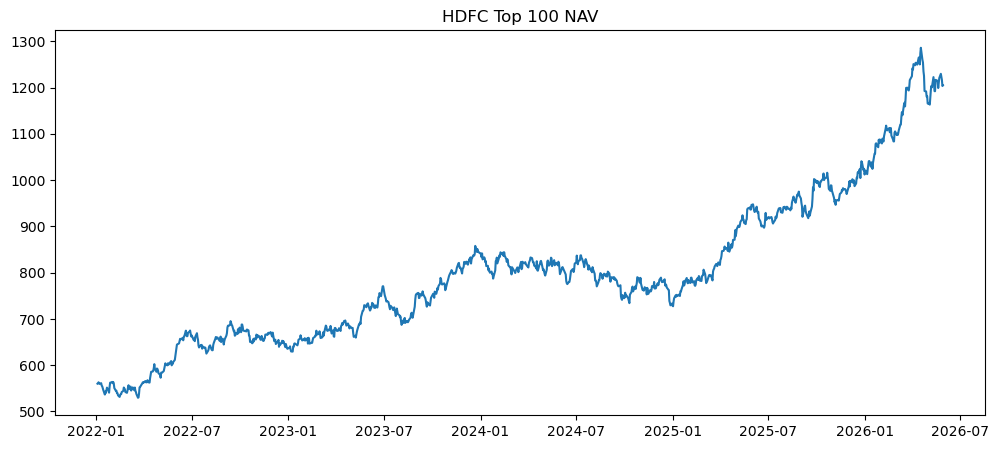

In [49]:
sample = nav_history[
    nav_history["amfi_code"] == 125497
]

plt.figure(figsize=(12,5))
plt.plot(sample["date"],sample["nav"])
plt.title("HDFC Top 100 NAV")
plt.show() 

#### AUM Growth

In [50]:
import seaborn as sns

In [ ]:
sns.barplot(
    data=aum,
    x="year",
    y="aum_crore",
    hue="fund_house"
)

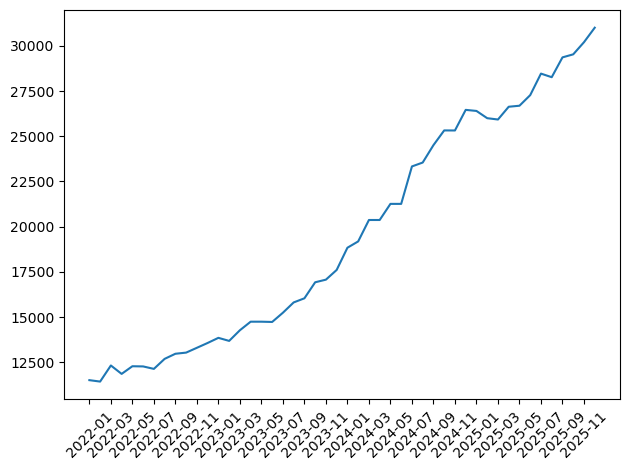

In [57]:
plt.plot(
    sip["month"],
    sip["sip_inflow_crore"]
)
plt.xticks(sip["month"][::2], rotation=45)
plt.tight_layout()
plt.show()

#### SIP trend

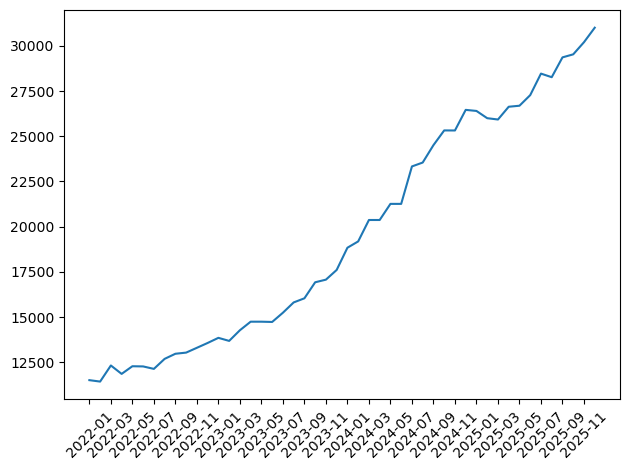

In [60]:
plt.plot(
    sip["month"],
    sip["sip_inflow_crore"]
)
plt.xticks(sip["month"][::2], rotation=45)
plt.tight_layout()
plt.show()

# Day 4

In [61]:
nav_history["daily_return"] = (
    nav_history.groupby("amfi_code")["nav"]
    .pct_change()
)

In [62]:
import numpy as np

rf = 0.065

sharpe = (
    nav_history["daily_return"].mean()*252-rf
) / (
    nav_history["daily_return"].std()*np.sqrt(252)
)

print(sharpe)

0.5755862237652256


In [12]:
%who

pd	 
